In [66]:
import json
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from core.normalizer import compute_wallmid1, compute_wallmid2, compute_wallmid3, compute_wallmid_ma

In [67]:
IPR = "INTARIAN_PEPPER_ROOT"
ACO = "ASH_COATED_OSMIUM"

#excel data
df_day1 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/prices_round_1_day_-2.csv", sep=";")
df_day2 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/prices_round_1_day_-1.csv",  sep=";")
df_day3 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/prices_round_1_day_0.csv",  sep=";")

df_day1_ipr = df_day1[df_day1["product"] == IPR]
df_day2_ipr = df_day2[df_day2["product"] == IPR]
df_day3_ipr = df_day3[df_day3["product"] == IPR]

df_day2_ipr["timestamp"] = df_day2_ipr["timestamp"] + 1000000 
df_day3_ipr["timestamp"] = df_day3_ipr["timestamp"] + 2000000

df_day1_ipr["mid_price"] = df_day1_ipr["mid_price"].ffill()
df_day2_ipr["mid_price"] = df_day2_ipr["mid_price"].ffill()
df_day3_ipr["mid_price"] = df_day3_ipr["mid_price"].ffill()

df_day1_aco = df_day1[df_day1["product"] == ACO]
df_day2_aco = df_day2[df_day2["product"] == ACO]
df_day3_aco = df_day3[df_day3["product"] == ACO]

df_day2_aco["timestamp"] = df_day2_aco["timestamp"] + 1000000 
df_day3_aco["timestamp"] = df_day3_aco["timestamp"] + 2000000
df_day1_aco["mid_price"] = df_day1_aco["mid_price"].ffill()
df_day2_aco["mid_price"] = df_day2_aco["mid_price"].ffill()
df_day3_aco["mid_price"] = df_day3_aco["mid_price"].ffill()

df_ipr = pd.concat([df_day1_ipr, df_day2_ipr, df_day3_ipr])
df_ipr["ask_price_1"] = df_ipr["ask_price_1"].ffill() 
df_ipr["bid_price_1"]= df_ipr["bid_price_1"].ffill() 

df_aco = pd.concat([df_day1_aco, df_day2_aco, df_day3_aco])
df_aco["ask_price_1"] = df_aco["ask_price_1"].ffill() 
df_aco["bid_price_1"]= df_aco["bid_price_1"].ffill() 
df_aco["ask_price_2"] = df_aco["ask_price_2"].ffill() 
df_aco["bid_price_2"]= df_aco["bid_price_2"].ffill() 
df_aco["ask_price_3"] = df_aco["ask_price_3"].ffill() 
df_aco["bid_price_3"]= df_aco["bid_price_3"].ffill() 

tf_day1 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/trades_round_1_day_-2.csv", sep=";")
tf_day2 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/trades_round_1_day_-1.csv",  sep=";")
tf_day3 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/trades_round_1_day_0.csv",  sep=";")

tf_day1_ipr = tf_day1[tf_day1["symbol"] == IPR]
tf_day2_ipr = tf_day2[tf_day2["symbol"] == IPR]
tf_day3_ipr = tf_day3[tf_day3["symbol"] == IPR]

tf_day2_ipr["timestamp"] = tf_day2_ipr["timestamp"] + 1000000
tf_day3_ipr["timestamp"] = tf_day3_ipr["timestamp"] + 2000000

tf_day1_aco = tf_day1[tf_day1["symbol"] == ACO]
tf_day2_aco = tf_day2[tf_day2["symbol"] == ACO]
tf_day3_aco = tf_day3[tf_day3["symbol"] == ACO]

tf_day2_aco["timestamp"] = tf_day2_aco["timestamp"] + 1000000
tf_day3_aco["timestamp"] = tf_day3_aco["timestamp"] + 2000000

tf_ipr = pd.concat([tf_day1_ipr, tf_day2_ipr, tf_day3_ipr])
tf_aco = pd.concat([tf_day1_aco, tf_day2_aco, tf_day3_aco])

#sim data
log_path=Path("/Users/alexoddsh/prosperity/backend/logs/166184.log")
data = json.loads(log_path.read_text())
ai = data["activitiesLog"]
th = data["tradeHistory"]
ied = data["logs"]

prices = pd.read_csv(io.StringIO(ai), sep=";")
trades = pd.DataFrame(th)

prices["day"] = 1
trades["day"] = 1

sim_df_ipr = prices[prices["product"] == IPR]  
sim_tf_ipr = trades[trades["symbol"] == IPR]
sim_df_ipr["ask_price_1"] = sim_df_ipr["ask_price_1"].ffill()
sim_df_ipr["bid_price_1"] = sim_df_ipr["bid_price_1"].ffill() 

sim_df_aco = prices[prices["product"] == ACO]
sim_tf_aco = trades[trades["symbol"] == ACO]
sim_df_aco["ask_price_1"] = sim_df_aco["ask_price_1"].ffill()
sim_df_aco["bid_price_1"] = sim_df_aco["bid_price_1"].ffill() 



Intercept: 9983.04
Slope: 0.0997


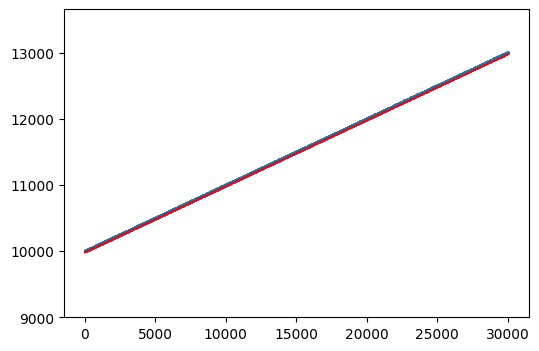

13.039466666666666
79480.0


In [68]:
X = df_ipr["timestamp"].to_numpy()
X = X / 100

X = np.column_stack([np.ones(len(X)), X])
Y = df_ipr["mid_price"]

beta = np.linalg.lstsq(X, Y, rcond=None)[0]

print(f"Intercept: {round(beta[0], 2)}")
print(f"Slope: {round(beta[1], 4)}")

t = np.linspace(0, 30000, 30000)
y = beta[0] + beta[1] * t

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X[:, 1], Y, s=1)
ax.plot(t, y , color='red')
ax.set_ylim(bottom=9000)
plt.show()

spread = df_ipr["ask_price_1"] - df_ipr["bid_price_1"]
print(spread.mean())
print(80*(10000*0.1-6.5))

The data is kinda noisy around this line in terms of the mid but imagine instead of the mid we had something more like wallmid, over the course of a day that is essentially a linear function for IPR. So we can model our optimization given that.

What we need to "optimize" is not the question of "is buying at different times better or worse". We would be just as well off. The question is rather do we sacrifice some of the long position. As we see from the regression, over the course of the day the price will essentially increase linearly by 0.0997 per tick, given this linear nature the optimal solutions are either of these:

1. Buy and hold. 80 * 10.000 * 0.1 = 80.000 Profit. The likely however will be a tiny bit lower due to vol and that we cannot fill all in the first timestamp. However also a bit minus since we will need to fill at the ask.  Avg spread is 13. Assuming that FV is at some kind of wallmid similar calc (we should check) then we are buying at circa 6.5 above FV. Real profit is:
-> 80 * (9990 * 0.1 - 6.5) = 79,000 - 79,500 ish.

2. Market make with long position. For simplicity, say that we then have two main variables. a) avg position LONG b) profit per market making vol. Profit becomes more like: 
-> Avg. Pos * (9990*0.1 - 6.5) + Avg.vol MM/timestamp * (10000) * Avg.profit per MM

We ofc need to maximize both. But these then depend on downstream variables. Avg.vol MM/timestamp and Avg.profit per MM is dependent on:
-> Volume Traded (limited by how large we want the avg position LONG to be)
-> How deep inside the spread quotes are/potential skew of bid to maintain LONG

Also the above doesn't even really work because we build the long by USING a skewed MM strat, how would we even separate the two?

Notice how the math gets real complex since volume traded may or may not have a large dependency on how deep inside the spread we quote, most years before it seems that enticing boths to shrink the spread isnt actually that effective, we will fill more opportunistic takers but the majority of fills are by real takers anyways, aka taking the best price, raising it from bid + 1 to bid + 4 for example doesnt seem to increase volume that much, the only added vol is the "opportunistic takers" but these dont contribute that much in PnL terms anyways. 

Now for strat nr.2 there is another mention, should we also apply the normal "taking logic"? aka were we take volume that we believe is profitable? This is taking all profitable bids/asks at t and then hopefully if we keep trading these takes closer to the bid are closed in the next few ticks before price has shifted above. 

This is actually something that would be possible to meaningfully compute a rule for. Since we know the price drift of 0.0997 per t and that FV and Wallmid (need to confirm this) has a very strong correlation then we could implement rule logic that the expected profit of a take at the ask is essentially EDGE - 0.0997 * avg holding ticks. Avg holding ticks could cant however be computed from back data, we would need to instead create some kind of probability model, what is the likelihood to get filled at the ask in the coming ticks for a similar or larger volume but this is hard since normal market making activities are always interfering. 

As I see it, our best options are either go for nr 1 stupid easy but free money maybe lose tiny bit of edge in round 1. Or better do option 2 but instead of trying to form what is likely going to be not a super accurate probability etc model to optimize, we could plug in our option 2 code to the gridtester and simply compute PnLs for 1000s of different rule combos. Slight problem with that is that it needs "constants" to form the rules over the whole trading day but since the trading day is literally just a linear function with some tiny added noise this could be OK. Option 3 try to via theory arrive at the mathematical optimal strat. 




      timestamp     error
1591      79500  1.850586
1588      79400  1.661133
1920      96000  1.640625


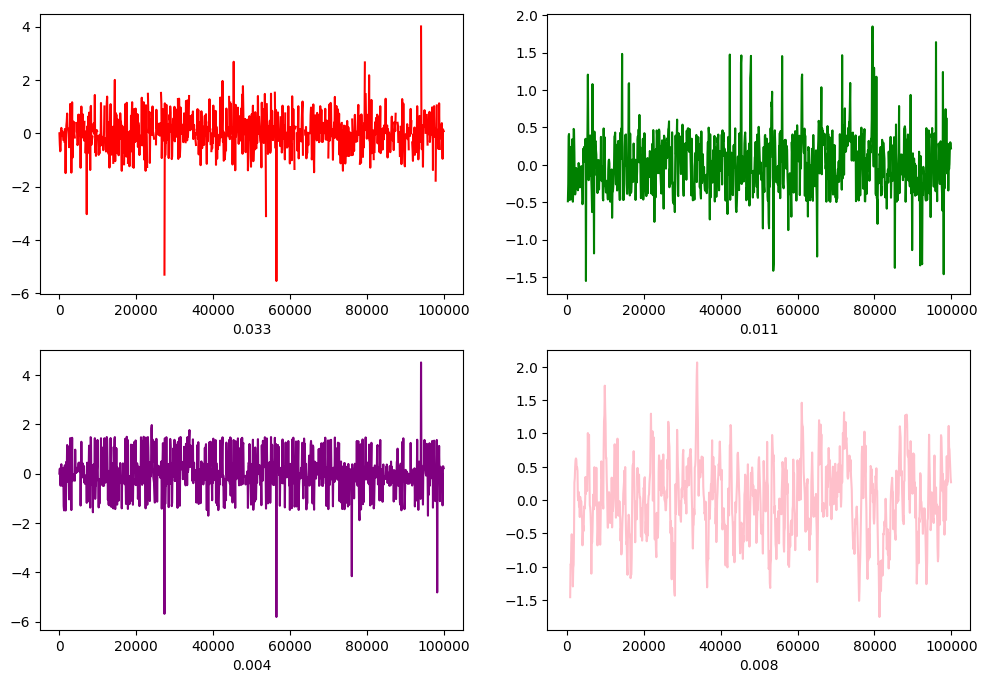

count    998.000000
mean       0.011269
std        0.397433
min       -1.554688
25%       -0.245850
50%       -0.011230
75%        0.265381
max        1.850586
dtype: float64
count    1000.000000
mean        0.003673
std         0.826542
min        -5.814453
25%        -0.367920
50%        -0.017578
75%         0.373047
max         4.510742
dtype: float64
count    992.000000
mean       0.008378
std        0.564565
min       -1.752539
25%       -0.357666
50%        0.004004
75%        0.403711
max        2.065625
dtype: float64


In [69]:
success = compute_wallmid3(ACO, sim_df_aco)
success = compute_wallmid1(ACO, sim_df_aco)
success = compute_wallmid2(ACO, sim_df_aco)

sim_df_aco_copy = sim_df_aco.copy()
sim_df_aco_copy["bid_price_2"] = sim_df_aco_copy["bid_price_2"].ffill()
sim_df_aco_copy["ask_price_2"] = sim_df_aco_copy["ask_price_2"].ffill() 
sim_df_aco_copy["bid_price_3"] = sim_df_aco_copy["bid_price_3"].ffill()
sim_df_aco_copy["ask_price_3"] = sim_df_aco_copy["ask_price_3"].ffill() 


prev = ""
for i in sim_df_aco.index:
    
    has_ask3 = pd.notna(sim_df_aco.loc[i, "ask_price_3"])
    has_bid3 = pd.notna(sim_df_aco.loc[i, "bid_price_3"])
    has_bid2 = pd.notna(sim_df_aco.loc[i, "bid_price_2"])
    has_ask2 = pd.notna(sim_df_aco.loc[i, "ask_price_2"])

    if has_ask3 and not has_bid3:
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco.loc[i, "ask_price_3"] + sim_df_aco_copy.loc[i, "bid_price_2"]) / 2
        prev ="3v2"

    elif has_bid3 and not has_ask3:
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_2"] + sim_df_aco.loc[i, "bid_price_3"]) / 2
        prev ="2v3"
    
    elif prev=="3v2":
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_3"] + sim_df_aco_copy.loc[i, "bid_price_2"]) / 2
        prev="0v0"

    elif prev=="2v3":
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_2"] + sim_df_aco_copy.loc[i, "bid_price_3"]) / 2
        prev="0v0"
    
    else:
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_2"] + sim_df_aco_copy.loc[i, "bid_price_2"]) / 2
        prev="0v0"

success = compute_wallmid_ma(ACO, sim_df_aco)

if success:
    entry_price = sim_tf_aco.iloc[0]["price"]
    trade_qty = sim_tf_aco.iloc[0]["quantity"]
        
    for i in sim_df_aco.index:
        mid_gap = sim_df_aco.loc[i, "mid_price"] - entry_price
        wall1_gap = sim_df_aco.loc[i, "wallmid1"] - entry_price
        wall2_gap = sim_df_aco.loc[i, "walllvl2"] - entry_price
        wall3_gap = sim_df_aco.loc[i, "wallmid3"] - entry_price
        wallma_gap = sim_df_aco.loc[i, "wallmidsma"] - entry_price
        
        mid_pnl = mid_gap *trade_qty
        wall1_pnl = wall1_gap * trade_qty
        wall2_pnl = wall2_gap * trade_qty
        wall3_pnl = wall3_gap * trade_qty
        wallma_pnl = wallma_gap * trade_qty

        sim_df_aco.loc[i, "mid_pnl"] = mid_pnl
        sim_df_aco.loc[i, "wall1_pnl"] = wall1_pnl
        sim_df_aco.loc[i, "wall2_pnl"] = wall2_pnl
        sim_df_aco.loc[i, "wall3_pnl"] = wall3_pnl
        sim_df_aco.loc[i, "wallma_pnl"] = wallma_pnl

    timestamps = sim_df_aco["timestamp"]
    pnls = sim_df_aco["profit_and_loss"]

    error_mid = (pnls - sim_df_aco["mid_pnl"]) / trade_qty
    error_wall1 = (pnls - sim_df_aco["wall1_pnl"]) / trade_qty
    error_wall2 = (pnls - sim_df_aco["wall2_pnl"]) / trade_qty
    
    top_n = 3 
    worst_idx = error_wall2.abs().nlargest(top_n).index
    print(sim_df_aco.loc[worst_idx, ["timestamp"]].assign(error=error_wall2.loc[worst_idx]))

    error_wall3 = (pnls - sim_df_aco["wall3_pnl"]) / trade_qty
    error_wallma = (pnls - sim_df_aco["wallma_pnl"]) / trade_qty 

    error_mid.iloc[0] = 0
    error_wall1.iloc[0] = 0
    error_wall2.iloc[0] = 0
    error_wall3.iloc[0] = 0
    error_wallma.iloc[0] = 0

    spread = sim_df_aco["ask_price_1"] - sim_df_aco["bid_price_1"]

    fig, ax = plt.subplots(2, 2,figsize=(12,8))

    ax[0, 0].plot(timestamps, error_wall1, color='red')
    ax[0,0].set_xlabel(round(error_wall1.mean(), 3))

    ax[0, 1].plot(timestamps, error_wall2, color='green')
    ax[0,1].set_xlabel(round(error_wall2.mean(), 3))

    ax[1, 0].plot(timestamps, error_wall3, color='purple')
    ax[1,0].set_xlabel(round(error_wall3.mean(), 3))

    ax[1, 1].plot(timestamps, error_wallma, color='pink')
    ax[1,1].set_xlabel(round(error_wallma.mean(), 3))
    
    plt.show()
    print(error_wall2.describe())
    print(error_wall3.describe())
    print(error_wallma.describe())

else:
    print("fuck")

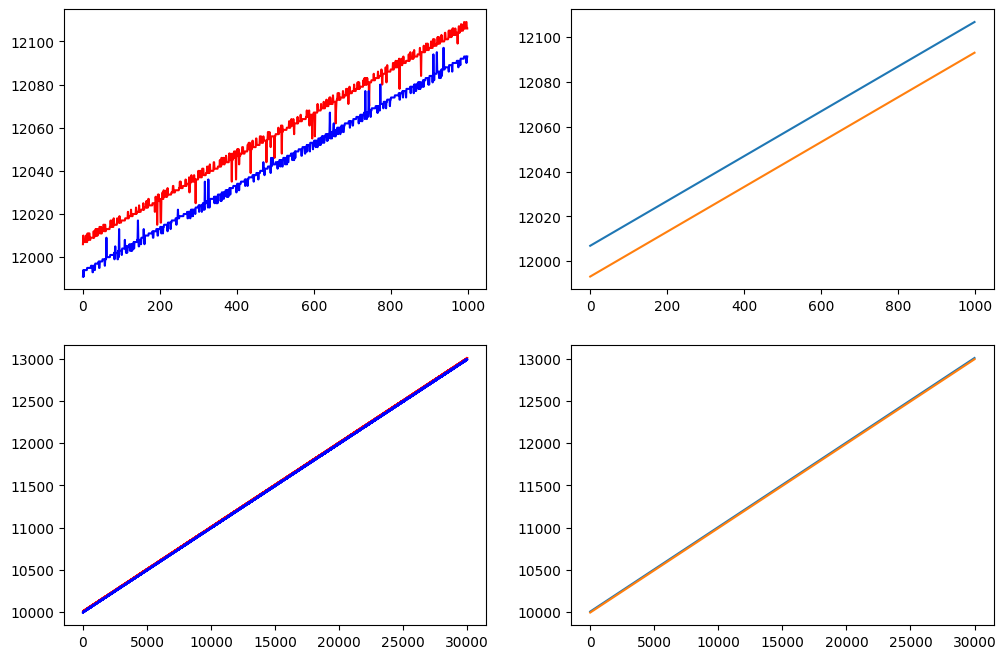

SIM DATA
Intercept Ask: 12006.882483516481
Intercept Bid: 11993.143548451548
Slope Ask: 0.09996699996699968
Slope Bid: 0.09999890199890209

3 DAYS HISTORY
Intercept Ask: 10005.68668519494
Intercept Bid: 9994.246857920298
Slope Ask: 0.10005373166694863
Slope Bid: 0.09994708548594125


In [70]:
#sim data
timestamps = sim_df_ipr["timestamp"].to_numpy() / 100
ask1 = sim_df_ipr["ask_price_1"]
bid1 = sim_df_ipr["bid_price_1"]
X = timestamps
X = np.column_stack([np.ones(len(X)), X])

beta_a = np.linalg.lstsq(X, ask1, rcond=None)[0]
beta_b = np.linalg.lstsq(X, bid1, rcond=None)[0]
y_a = beta_a[0] + beta_a[1] * timestamps
y_b = beta_b[0] + beta_b[1] * timestamps

sim_df_ipr["y_a"] = y_a
sim_df_ipr["y_b"] = y_b
sim_df_ipr["regwall"] = (sim_df_ipr["y_a"] + sim_df_ipr["y_b"]) / 2

#history data
timestamps_h = df_ipr["timestamp"].to_numpy() / 100
ask1_h = df_ipr["ask_price_1"]
bid1_h = df_ipr["bid_price_1"]
XH = timestamps_h
XH = np.column_stack([np.ones(len(XH)), XH])
beta_ah = np.linalg.lstsq(XH, ask1_h, rcond=None)[0]
beta_bh = np.linalg.lstsq(XH, bid1_h, rcond=None)[0]
y_ah = beta_ah[0] + beta_ah[1] * timestamps_h
y_bh = beta_bh[0] + beta_bh[1] * timestamps_h

#figs
fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0, 0].plot(timestamps, ask1, color='red')
ax[0, 0].plot(timestamps, bid1, color='blue')
ax[0, 1].plot(timestamps, y_a)
ax[0, 1].plot(timestamps, y_b)

ax[1, 0].plot(timestamps_h, ask1_h, color='red')
ax[1, 0].plot(timestamps_h, bid1_h, color='blue')
ax[1, 1].plot(timestamps_h, y_ah)
ax[1, 1].plot(timestamps_h, y_bh)

plt.show()

print("SIM DATA")
print(f"Intercept Ask: {beta_a[0]}")
print(f"Intercept Bid: {beta_b[0]}")
print(f"Slope Ask: {beta_a[1]}")
print(f"Slope Bid: {beta_b[1]}")
print("")

print("3 DAYS HISTORY")
print(f"Intercept Ask: {beta_ah[0]}")
print(f"Intercept Bid: {beta_bh[0]}")
print(f"Slope Ask: {beta_ah[1]}")
print(f"Slope Bid: {beta_bh[1]}")


count    1000.000000
mean      -49.954487
std        28.877042
min       -99.895984
25%       -74.925242
50%       -49.954500
75%       -24.983758
max         0.000000
dtype: float64


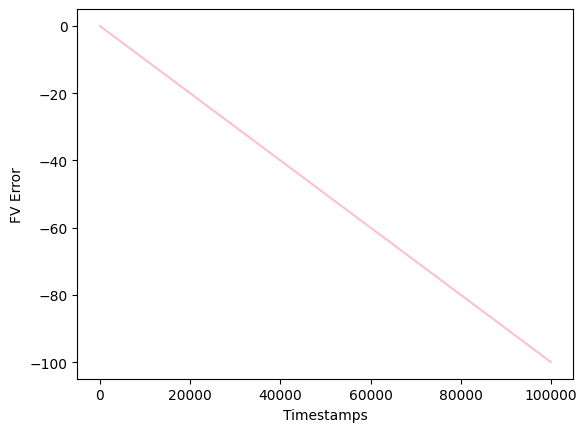

In [71]:
#Potential OP strategy

entry_price = sim_tf_ipr.iloc[0]["price"]
trade_qty = sim_tf_ipr.iloc[0]["quantity"]

for i in sim_df_ipr.index:
    wallmid = sim_df_ipr.loc[i, "regwall"]

    regwall_gap = wallmid - entry_price
    regwall_pnl = regwall_gap *trade_qty

    sim_df_ipr.loc[i, "regwall_pnl"] = regwall_pnl
    
timestamps = sim_df_ipr["timestamp"]
pnls = sim_df_ipr["profit_and_loss"]

error_regwall = (pnls - sim_df_ipr["regwall_pnl"]) / trade_qty
error_regwall.iloc[0] = 0

print(error_regwall.describe())

plt.plot(timestamps, error_regwall, color='pink')
plt.ylabel("FV Error")
plt.xlabel("Timestamps")
plt.show()


## How to check for mean reversion

### Standard Dickey Fuller Test & OLS
We should probably always start with the DF test. To understand the DF test we must first understand the autoregressive process. At the base level it is fairly simple, we check the correlation between points in a timeseries and lagged points to see if they have any correlation. The idea is that if we have pearson correlation between data at $t$ and $t_{-1}$ then $t_{-1}$ can be used to "predict" future behaviour. IF this correlation is below 1 then the timeseries is essentially "being pulled back". 

To understand this we must move away from the idea that our series has any kind of "sign", every series we think about here first has the mean normalized to 0 otherwise this does not work. An example, if the mean is 20 and we have a pearson correation of 0.8 and $t_{3} = 30, t_{-2} = 30 \cdot 0.8, t_{-1} = 30 \cdot 0.8^2 ...$ for a while we are always getting closer to 20 but then we cross 20 and start moving away from it (not mean reversion.) To make the rules work we would first normalize a series to mean = 0. 

NOW if we have the same $\phi = 0.8$ then this correlation value literally means that we are moving closer to 0 at all times. IF currently above zero then the value gets smaller each tick, if random noise causes us to go below 0, say $t_{-1} = -5$ then $t = -5 \cdot 0.8 = -4$ is also moving towards the mean 0. 

Now the DF test is based on this simple idea. We have a time series and want to know is it stationary (mean reverting) or does it have a unit root (random walk). The benefit of doing this test first is that it is binary, if we cannot reject the null here then additional analysis is useless. Start with the simple autoregressive process:

$$y_t = \mu + \phi \cdot y_{t-1} + \varepsilon_t$$

Here:
- $y_t$ = Value at t
- $\mu$ = The intercept (m-value)
- $\phi$ = The slope (k-value)
- $\varepsilon$ = Noise/random shock (aka for example the random takers in ACO)

From the discussion above we know that anything mean reverting (stationary) requires $\phi < 1$ aka a "slope" smaller than 1 so that $y_t$ is moving closer to 0 than $y_{t-1}$. Note to not get confused here with an actual $y=kx+m$ where we would need a negative slope because here the "input" $X$ is just one lagged value and we want the output $y$ to be closer to the zero mean. 

Now subtract $y_{t-1}$ from both sides:

$\Delta y_{t} = \alpha + \rho \cdot y_{t-1} + \varepsilon_t$

Where $\rho = \phi - 1$. This is simply done to reparam the slope, now instead of testing $\phi = 1$ we test $\rho = 0$. Nothing different just cleaner to work with. Now we run OLS of $\Delta y_t$ on $y_{t-1}$ to find $\alpha$ and $\hat{\rho}$.

Let's do a quick rerun of how OLS works. We have data and want to fit it to: $y = kx + m$ or also expressed $f(x) = \alpha + \beta \cdot x_t$ and we need to find the intercept and slope. OLS minimizes the sum of the squared residuals (errors) between the line and the data points. We square because negative and positive distances should not cancel AND so that larger errors are more penalizing exponentially. 

Now from the OLS we also get the SSE (Sum of Squared Errors) this is what OLS is minimizing. The SE (standard error) is the uncertainty in our estimate $\hat{\rho}$. Now SE as we know it is $SE = \frac{\sigma}{\sqrt{n}}$ but that is just the general case for a sample mean $\mu$. To understand the SE for a regression coefficient we need to understand how to find $\beta$. 

Objective is to minimize $S(\alpha, \beta) = \sum(y_i - \alpha - \beta x_i)^2$. Now this is a squared function so it gives a convex shape. If $S$ was dependent on one variable this would be the standard high-school setup, convex function and derivative = 0 gives minima. The same applies for two variables. $S$ is a 3D shaped bowl essentially and we want the global minima where both derivatives are 0. For this we have FOCs:

- $\frac{\partial S}{\partial \alpha} = 0$
- $\frac{\partial S}{\partial \beta} = 0$

Using the chain rule to find the partial derivatives we get:

- $\frac{\partial S}{\partial \alpha} = -2\sum(y_i - \alpha - \beta x_i) = 0$
- $\frac{\partial S}{\partial \beta} = -2\sum x_i(y_i - \alpha - \beta x_i) = 0$

Now solve the first FOC, from it we have:
$\sum(y_i - \alpha - \beta x_i) = 0$ -> $\sum y_i = n\alpha + \beta\sum x_i$ and dividing by n:
-> $\bar{y} = \alpha + \beta \bar{x}$ -> $\hat{\alpha} = \bar{y} - \hat{\beta}\bar{x}$

Now use the result above and substitute into the second FOC:
$\sum x_i(y_i - (\bar{y} - \hat{\beta}\bar{x}) - \beta x_i) = 0$ and rearrange this into:

$$\sum x_i(y_i - \bar{y}) = \hat{\beta} \sum x_i(x_i - \bar{x})$$

Now use the following identity based on the trivially true $x_i = (x_i - \bar{x}) + \bar{x}$:

$$\sum x_i(x_i - \bar{x}) = \sum [(x_i - \bar{x}) + \bar{x}](x_i - \bar{x}) = \sum(x_i - \bar{x})^2 + \bar{x}\sum(x_i - \bar{x})$$

Now note that this second term always vanishes because all the deviations from the mean always sum to 0. Why? well think like this x bar is just the average deviation, multiplying it by N (aka summing for all deviations) just gives the same total as summing all the deviations so subtracting them is 0. Now we are left with:

$$\sum(x_i - \bar{x})^2$$

Applying this logic to both sides of the FOC expression above:

$$\sum(x_i - \bar{x})(y_i - \bar{y}) = \hat{\beta}\sum(x_i - \bar{x})^2$$

And then solving for $\hat{\beta}$:

$$\hat{\beta} = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$$

Which we can note is exactly sample covariance (x, y) / sample variance (x). Intuition: the slope scales how much y moves with x relative to how much x in the data moves on its own. Almost like the avg $\frac{\Delta y}{\Delta x}$ across the whole dataset.

Now back to SE, we want to find the variance of our estimator $\hat{\beta}$. Now do some (very long subs) using the formula for $\hat{\beta}$ and get:

$$\text{Var}(\hat{\beta}) = \frac{\sigma^2}{\sum(x_i - \bar{x})^2}$$

So:

$$SE(\hat{\beta}) = \frac{\sigma}{\sqrt{\sum(x_i - \bar{x})^2}}$$

For $\sigma^2$ we use the approximation:

$$\sigma = \sqrt{\frac{SSE}{N-k}}$$

The SE of beta essentially tells us what the deviation in our estimate is. We have the standard deviation of the SSE which logically is a metric capturing how much our estimator varies since SSE is what the estimator is trying to minimize. Then we divide by the spread of X, aka how much variance we have in the regressor. This is logical, if X is spread wider our divisor becomes larger, aka the SE decreases. This makes sense just geometrically visualizing OLS, if we have a lot of X very close to each other that we are trying to fit a line to, this fitting becomes worse than if we have Xs wider apart. 

So back to DF. We have $\hat{\rho}$ from our OLS. But remember this is an estimator, to test it against a hypothesis we also need a sufficient degree of certainty that the estimator itself is correct. 

Now for the hypothesis:

- $H_0: \rho = 0$ -> Unit root, non-stationary (because $\phi$ is 1 if $\rho$ is 0, and IF $\phi = 1$ then no mean reversion)
- $H_1: \rho < 0$ -> Mean-reverting, stationary ($\phi$ is smaller than 1)

But to reject $H_0$ we as stated above need sufficient certainty in $\hat{\rho}$. For this we use a t-stat. The t-stat measures how many standard errors an estimate is from zero. The t-stat is essentially a signal to noise ratio. For $\hat{\beta}$ specifically:

$$t = \frac{\hat{\beta}}{SE(\hat{\beta})}$$

In our thesis above we want to REJECT that $\rho = 0$. So how far from 0 does the $\hat{\rho}$ estimate need to be so that it is unlikely enough that $\rho$ is indeed not 0? If $\hat{\rho} = 4$ and $SE = 2$ then our estimator is only 2 standard errors away, $\rho$ could very well actually be 0. If $\hat{\rho} = 20$ however and $SE = 2$ then our estimator is 10 standard errors away, virtually impossible that $\rho$ would be 0.

Now the t-stat, the p-stat and a Confidence Interval all explain the same underlying thing. Now this is EXACTLY what we have already worked a lot with in stats, we are just used to going the other way around working with distributions. We are used to a given $\mu$ and $\sigma$ and asking how likely is a random draw to land this far out/in from the mean. We are then used to computing a z-score $z = \frac{x-\mu}{\sigma}$ that tells us how many standard deviations away is our measurement from the mean. From this we might end up with something like 2 and then conclude that the probability of a draw landing this far out from the mean is 2.3% according to the normal distribution. 

Then we might say that 95% of all values fall within $\pm 1.96$ standard deviations away from the mean. Now the point is that these are the same concepts as we apply to regressions. 

- T-stat = z-val: $$z = \frac{x-\mu}{\sigma} \rightarrow t = \frac{\hat{\beta}-0}{SE(\hat{\beta})}$$ 

- P-stat: For a distribution this is something we simply read/descriptive. If our value $X = \mu + 2\sigma$ then the p-value is just the tail probability beyond that point, aka what is the probability of drawing a value at least this extreme. In the regression case we don't have a known distribution to read off. Instead we assume that the null hypothesis $\rho = 0$ is true which gives a distribution for $\hat{\rho}$ centred at 0: $\hat{\rho} \sim N(0, SE(\hat{\rho})^2)$. Then we ask, IF this null hypothesis were true, what is the probability to observe as extreme a $\hat{\rho}$ as we did? Here we are aiming for this to be as low as possible, ideally $p < 0.05$ which means that IF the null was true, there would only be a 5% chance that we would see this value. 

- CI: For a distribution ex: "95% of all datapoints fall within $\mu \pm 1.96\sigma$" so we can with a 95% confidence say that our statistic $\beta$ is in [0.5, 2.5] for example. For a CI in a regression the framing is slightly different. We are saying "if the study was conducted 100 times, 95 of the constructed intervals would contain the true $\beta$".

Explaining the CI framing above. From OLS theory we can prove that the distribution of $\hat{\beta}$ follows a normal distribution:

$$\hat{\beta} \sim N(\beta, SE(\hat{\beta})^2)$$

So $\hat{\beta}$ IS normally distributed centered on the true $\beta$. Imagine true $\beta$ on a number line/probability space:

- True $\beta$ is at a fixed point, for example 10. 
- Every sample gives a $\hat{\beta}$ drawn from this normal dist centered around 10.

Now we can construct a CI around every $\hat{\beta}$. If our $\hat{\beta}$ falls sufficiently close to true $\beta$ then this true $\beta$ will be included in the 95% confidence interval. Imagine for example that the $\hat{\beta}$ we get is a bit left on the probability space to true $\beta$, if sufficiently close then the confidence interval around $\hat{\beta}$ "reaches back" to include true $\beta$. BUT the 5% of $\hat{\beta}$ that fall too far to the right or left of true $\beta$ on the probability space then in turn have CIs that do NOT include true $\beta$. This is why the expression is not about $\hat{\beta}$ itself, either true $\beta$ is inside its confidence interval or it is not. What we state is about the procedure, doing this 100 times means that in 95 of the CIs constructed around $\hat{\beta}$ will this CI include true $\beta$. 

Now revisiting the hypothesis:

- $H_0: \rho = 0$ -> Unit root, non-stationary (because $\phi = 1$ if $\rho = 0$, and IF $\phi = 1$ then no mean reversion)
- $H_1: \rho < 0$ -> Mean-reverting, stationary ($\phi$ is smaller than 1)

Note that we do not care about $\rho > 0$ at all, this would mean that $\phi > 1$ hence the data would be diverging/expanding from the mean which is not what we want. Now the core thing here is that we need a p-stat where $p < 0.05$ in order for it to be sufficiently unlikely that our rejection of the null is incorrect. BUT whereas the standard $\beta$ in an OLS follows a normal distribution where we can use critical values $|t| > 1.96$ for $p < 0.05$, this is not true for the DF null. 

Instead the null follows the Dickey-Fuller distribution. So we need special critical values:

| Significance level | Critical value |
|---|---|
| 10% | -2.57 |
| 5% | -2.86 |
| 1% | -3.43 |

So we REJECT the null and thus conclude that the data may be mean-reverting IF our t-value is more negative than -2.86 for a p-stat of 0.05. As we can conclude this test in itself isn't super useful because we don't know how fast/slow something mean reverts, just that it does so in our dataset. This is why this is the first logical test to make before moving on to checking how fast/slow. 

### Augmented Dickey Fuller
Now the problem with the standard test above is that we assume that the error term $\varepsilon_t$ is independent identically distributed BUT in practice real time series often have autocorrelated errors. Today's residual is correlated with yesterday's. 

This makes a lot of sense, imagine we have a product such as ACO where price is mean reverting but the price looks noisy due to small takers coming in and crossing the spread. These takers often cause the mid price to shift momentarily for a few ticks when they enter the market before it shifts back to where it was when they exit, so their presence is pure error / white noise. Importantly, this example showcases that the error terms at each tick aren't some independent variable. If our taker enters at t=10 they often stick around a few ticks until t=15 until they are satisfied with their filled orders. Hence the error at t=11, 12, 13 etc is directly correlated with the error at t=10.

If we used the standard test on the above we would risk the outcome being invalid. The Augmented Dickey-Fuller test fixes this problem by adding lagged differences of the dependent variable to soak up autocorrelation in the errors. So we essentially add more regressors for previous lags, now we essentially include whatever effects these previous lags had on $\Delta y_t$ so that our regressor $\rho$ is specifically only examining the relationship between $y_{t-1}$ and $\varepsilon_t$. Formally:

$$\Delta y_t = \alpha + \rho y_{t-1} + \delta_1 \Delta y_{t-1} + \delta_2 \Delta y_{t-2} + ... + \delta_p \Delta y_{t-p} + \varepsilon_t$$

Note however that this has 2 problems. Nr 1 overfitting: with too many lags we simply start fitting to a lot of noise. We also have the standard problem with many regressors regarding multicollinearity, price changes at different times tend to be correlated with each other. Very often in financial data price at t-1 and t-2 is correlated, now OLS needs to isolate the independent contribution of each regressor to explain $\Delta y_t$. If prices are correlated then you cannot cleanly separate the individual effects into the individual regressors. Now how good these individual regressors are isn't important for ADF so the standard problem of separating effects when running multiple regressors is not present in the same way BUT the standard error increases a lot making it harder to reject the null hypothesis. 

Furthermore, more params also reduces the degrees of freedom. Let's say we have N observations. Each data point carries information. A degree of freedom is essentially how many units of that information is available to estimate something, so of course we generally want higher degrees of freedom. Let's take a dead simple example:

Say you have 3 observations: y = [2, 4, 6]. You want to estimate the mean and the variance.
Mean = (2+4+6)/3 = 4. You used all 3 observations to compute this.
Now you want to estimate variance, how spread out are the observations? You compute deviations from the mean: [-2, 0, +2].

But there is a problem, these 3 deviations are not "free", the sum of the deviations must sum to 0 by construction as the mean was computed from the same data. Think about it, if we use 3 datapoints to compute a mean then we are saying that the deviations of these datapoints and this mean are symmetric around the mean (aka sum to 0). So if we know that the first two deviations here are [-2, 0] then the third needs to be 2 by design, thus only two of our three deviations actually carry independent information about the spread of the data. This is why sample variance is divided by n-1 and not n. One of the deviations of all our deviations to the mean must be whatever gives that the sum of the deviations $\sum(y_i - \bar{y}) = 0$ since $\bar{y}$ was computed from the same data. 

The same idea applies to our OLS. Imagine this, if we had 3 rows of time series data and fitted 3 regressors each for each lag then our residuals (and the SSE) would always be 0. We are essentially not estimating anything at all anymore, we are calculating an exact solution of regressors that fits the data. Since the SSE is 0 the variance and SE is 0. Think like this, variance should measure the unexplained variation but if we fit a param to every datapoint then no data ever goes unexplained, we are simply measuring it by construction. Look at the formula for the SE estimate:

$$SE(\hat{\beta}) = \frac{\sigma}{\sqrt{\sum(x_i - \bar{x})^2}}$$

And:

$$\sigma = \sqrt{\frac{SSE}{N-k}}$$

And here we directly see algebraically how the degrees of freedom affects the standard error. K is the number of parameters we add. For the simple model just k=1. If we add lags (ADF) then we introduce more, if we add a constant $\alpha$ as an intercept we add one more param. If we add a trend we add one more etc. 

Now critically, my previous Prosperity example was purely for illustrative purposes but actually the real dynamic in Prosperity is quite the opposite. The orderbook resets each tick so each tick and the information it carries including the error/noise that tick is actually more independent than we think, which actually argues for NOT using ADF. The motivation for augmentation disappears since it just consumes degrees of freedom and risks overfitting for no reason. 

### 3 Dickey Fuller Model Variants
Now critically the DF test has 3 variants. 

1. Pure Random Walk (no constant/intercept, no trend)
Assumes that the prices are centered around 0, not appropriate in our case.
$$\Delta y_t = \rho \cdot y_{t-1} + \varepsilon_t$$

2. Random Walk with Intercept (constant, no trend)
Assumes an intercept, a lot more like what we would expect from ACO, where we have no trend and price seems to oscillate around 10K.
$$\Delta y_t = \alpha + \rho \cdot y_{t-1} + \varepsilon_t$$

3. Random Walk with Intercept and Trend (constant + trend)
Assumes the series systematically trends somewhere and the model instead asks if the prices are stationary (mean reverting) around this trend. 
$$\Delta y_t = \alpha + \gamma t + \rho \cdot y_{t-1} + \varepsilon_t$$

### If we can reject the NULL?
So if we can do the above the next logical question is how fast does it mean revert? If it is over too long or short a time it is untradeable. The standard method is to inspect the half-life, how many ticks does it take for a deviation from the mean to decay by half? This is an arbitrary decay rate but we use it because it is easy to compare and understand. The math becomes:

- Deviation at t: $\phi^t \cdot \text{deviation at } t=0$
- $\phi^t = 0.5 \rightarrow t \cdot \ln(\phi) = \ln(0.5) \rightarrow t = \frac{\ln(2)}{-\ln(\phi)}$

Where $\phi = 1 + \rho$, since we need the actual AR(1) multiplier rather than the reparametrized DF coefficient. So equivalently:

$$HL = \frac{\ln(2)}{-\ln(1 + \rho)}$$

So for trading purposes, we might find that the HL is 50-100 ticks = very tradeable. Sub 5-10 ticks is probably not useful. Remember that what we are actually interested in at all times is FV, not price. Price may fluctuate however but the key to a profitable strategy is being able to estimate/compute/predict FV and then COMPARE to price, we must drop the standard "buy low sell high" ideas. Any trades we make must be where FV is good relative to price, not where price entered is good relative to price exited. Any underlying metric we run the Dickey Fuller test on will never be FV precisely (because we don't know FV), it will be a proxy such as wallmid which we hopefully via the sims PnL stats have confirmed has a symmetric and low variance around true FV. 

Our current metric seems to be spread symmetrically around FV with std = 0.25 and the max and min error being $\pm 0.5$ with a mean of 0.0042. The point is that it is almost literally impossible to 100% isolate this wallmid metric from market microstructure noise. We have managed to for some very simple products but still. 

Hence if we have a half life that is too small then this is likely attributable to the market noise constantly interfering with our metric. This is also why we must examine the size of deviations in absolute terms. If the product is mean reverting around price = 10,000 but the spread is oscillating between 10,005 and 9,995 with a very short half life then we'll likely just be chasing a bunch of noise, very hard to find a good ruleset for when to execute vs not. And even if we do detect something, if the half life is too small then the reversion will fade too quickly anyway. If half life is 5 ticks and remember we only observe what happened during a tick AFTER it happens, as with all market data it is backwards looking so we don't execute anything until t+1 and might not be able to get a good fill until t+2 or t+3, here a large chunk of decay has already occurred. 

### Measuring the size of the Deviations
The best way is to look at z-scores. How many standard deviations is the current price away from the mean. The practical workflow would be: estimate the mean, estimate the standard deviation from historical deviations, then in the algo compute the z-score at each tick. Compare to the empirical distribution of z-scores for this product, what does a large deviation actually look like and build an entry/exit system around this. 


## Practical Cookie-Cutter Action Plan

**1. Inspection of the time series.** Determine which one of our 3 DF variants are appropriate: 
- Trends systematically $\rightarrow$ Variant 3
- Oscillates around constant mean $\rightarrow$ Variant 2

**2. Run Standard Dickey-Fuller.**
Run OLS on whatever variant we picked. Remember to reparametrize by subtracting $y_{t-1}$ from both sides of the expression. Note that before running we must decide on the needed constants for possible intercept and drift which we would likely compute as we have done previously, imagining the timeseries as a straight $y=kx+m$ and fitting a regression to get a straight line through the middle between the bid and ask. Essentially trying to create a function version of wallmid. 

After the OLS, look at the t-stat for $\hat{\rho}$. Compare it against the critical values of the DF distribution (non-normal). If $t < -2.86$ reject the null with a p-stat $< 0.05$, aka 5% or less likelihood that we are incorrect. Proceed to next step. 

**3. Compute half life** using the standard formula:
$$HL = \frac{\ln(2)}{-\ln(1 + \rho)}$$
- If $10 < HL < 200$ ticks $\rightarrow$ tradeable
- If $HL < 10$ ticks $\rightarrow$ mostly noise, too quick decay ruins edge
- If $HL > 200$ ticks $\rightarrow$ too slow, too few trades within a round

**4. Deviation Sizing - Finding what moves are significant.**
If we still believe in a possible strategy, compute z-scores of our FV proxy (wallmid) against its historical mean and standard deviation. Formally:

$$\mu_{wallmid} = \frac{1}{T}\sum_{t=1}^{T} wallmid_t$$

$$\sigma_{wallmid} = \sqrt{\frac{\sum(wallmid_t - \mu)^2}{T-1}}$$

$$z_t = \frac{wallmid_t - \mu}{\sigma}$$

We aim to answer 2 questions: 
- How large a $z^*$ is frequent enough to generate trades but also statistically significant? Given $z_t > z^*$, what is the average $z_{t+k}$ for $k = 1, 2, 3...$ ticks? If the signal is real, $z$ should decay back toward 0 predictably. This is just confirming the mean reversion dynamic is detectable and consistent at this threshold. 

- EVEN if we can form a rule to detect statistically valid signals that occur often enough via the z-scores, is the deviation then in absolute terms large enough to be profitable? Especially after considering that we probably want to cross the spread as takers to execute quickly:

$$\text{expected absolute deviation} = z^* \cdot \sigma_{wallmid}$$

Then we can formally check the profit condition accounting for how large the spread is:

$$z^* \cdot \sigma_{wallmid} > 2 \cdot \text{spread cost}$$

Note times 2 assumes that we want to act as takers both during the entry and exit. Also note that spread cost is not the bid ask spread, it is the difference between expected FV and entry/exit. Assume the following: we have detected a z-score that indicates that price is soon likely to decay back to mean, we want to enter as a taker at the bid selling into a short position. Since FV is basically always somewhere inside the ask/bid spread we need to take this trade selling below FV, which is essentially a cost for making this bet as a taker executing quickly. Same goes for when we exit. 

But note this assumes a short timebase strategy where quick entry/exit is crucial. If the mean reversion has a longer timespan then we might increase profits by exiting/entering as a maker. Doubt we have time to compute it but formally we would check the cost of being a taker vs what we lose from a slower entry/exit due to the decay.

**5. IF satisfied with the above, build Entry/Exit Rules around z-score thresholds:**
- If $z > z^*$ $\rightarrow$ execute trade betting on mean reversion
- If $z \approx 0$ $\rightarrow$ exit position, mean reversion is now complete

Larger $z$ $\rightarrow$ more certainty that the deviation will mean revert $\rightarrow$ larger position.

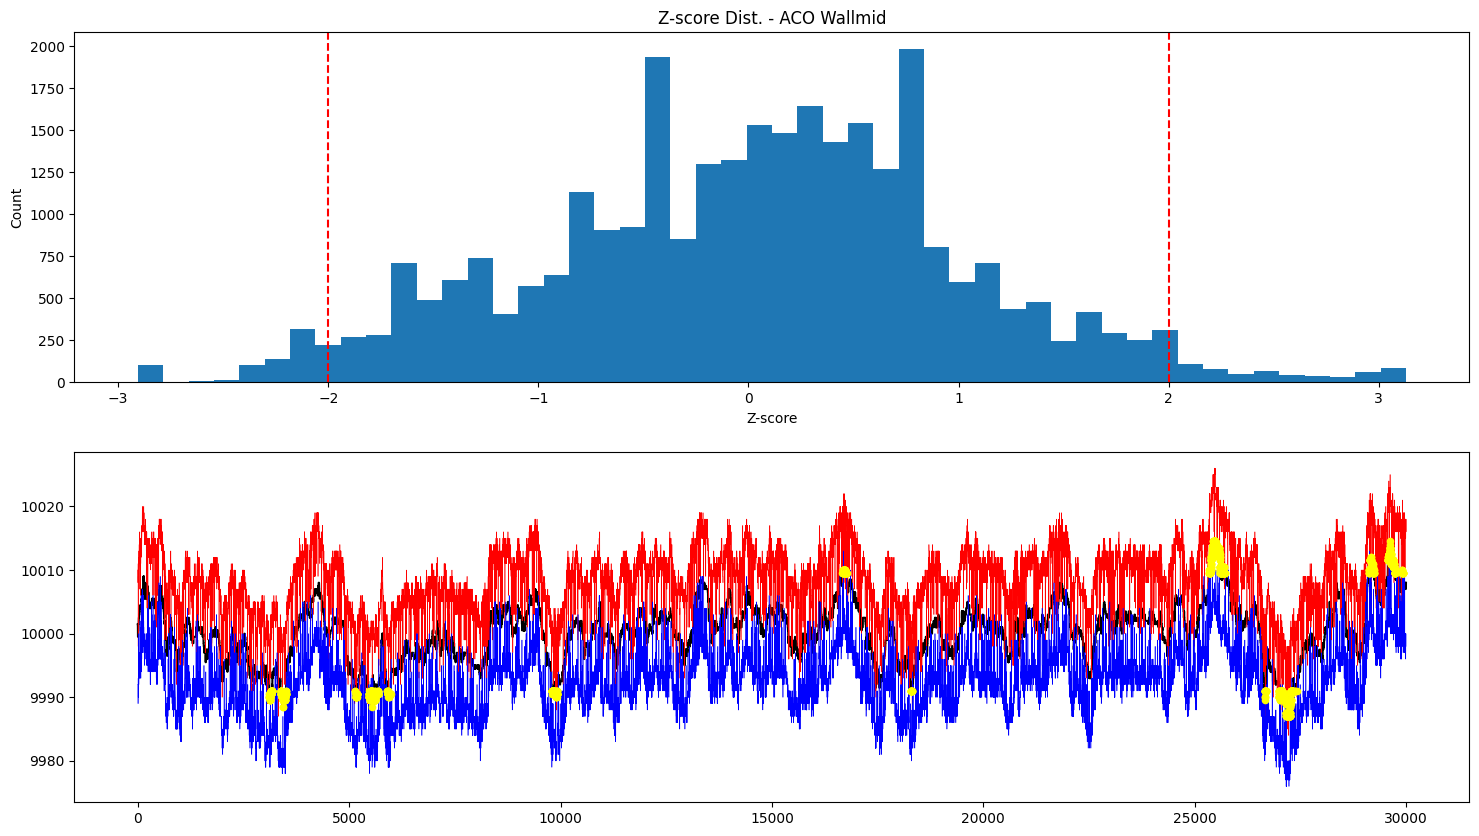

NULL HYPOTHESIS REJECTED: True
RHO: -0.0023058531254048385
PHI: 0.9976941468745951
REG INTECEPT: 23.059304656301364
T-STAT: -5.825016120849038
P-VAL: 4.0985580760802685e-07
Half Life: 300.2566458641506
Mean Wallmid: 10000.2417
Std. Wallmid: 4.5557918760614236
Z-Score Signals: 49


In [76]:

#Step 1/2 DF test
compute_wallmid3(ACO, df_aco)
wallmid = df_aco["wallmid3"].ffill().bfill().to_numpy()
null_reject = False

#regression "c" -> variant 2 and "ct" = variant 3
#c for constant, t for trend
#Autolag=none means not augmented

result = adfuller(wallmid, maxlag=0, regression="c", autolag=None)
#adfuller returns t, p, rho hat

t_stat = result[0]
p_val = result[1]
critical_values = result[4]

if t_stat < critical_values["5%"]:
    null_reject = True

# Get Rho/Phi since adfuller doesnt extract it

#Note that this OLS will get RHO not PHI since we use delta y aka we have reparamaretized the original autoregression
#By subtracting y_{t-1} on both sides. Means the left side becomes delta Y and right side we use Rho = (Phi - 1) instead of
#Phi as the coefficient.

if null_reject:
    delta_y = np.diff(wallmid) #1st observation is dropped
    y_lag = wallmid[:-1] #1st observation is dropped
    X = add_constant(y_lag) #Just adds a column of ones so we have a 2D array where the 1s are used for the intercept alpha
    ols_res = OLS(delta_y, X).fit()
    intercept = ols_res.params[0]
    rho = ols_res.params[1]
    phi = rho + 1
    
    #Step 3 Check HL
    half_life = np.log(2) / -np.log(phi)

    #Step 4 check size and number of deviations and distribution
    mu_wallmid = wallmid.mean()
    sigma_wallmid = wallmid.std(ddof=1) #note delta degrees of freedom = 1 we want sample sigma!
    z_scores = (wallmid - mu_wallmid) / sigma_wallmid
    
    #check 
    above = np.abs(z_scores) > 2.0 #bool array
    crossings = np.diff(above.astype(int)) #convert bool array to 0,1s then do diff and we will have the crossings
    entry_signals = np.sum(crossings == 1)
    entry_times = np.where(abs(z_scores) > 2.0)[0]

    fig, ax = plt.subplots(2 , 1, figsize=(18, 10))
    ax[0].hist(z_scores, bins=50)
    ax[0].set_title("Z-score Dist. - ACO Wallmid")
    ax[0].axvline(x=2, color="red", linestyle="--")
    ax[0].axvline(x=-2, color="red", linestyle="--")
    ax[0].set_xlabel("Z-score")
    ax[0].set_ylabel("Count")

    ax[1].plot(wallmid, color="black")
    ax[1].plot(df_aco["ask_price_1"].ffill().bfill().to_numpy(), color="red", linewidth=0.4)
    ax[1].plot(df_aco["bid_price_1"].ffill().bfill().to_numpy(), color="blue", linewidth=0.4)
    ax[1].scatter(entry_times, wallmid[entry_times], color="yellow", s=20, zorder=5, marker="o")

    plt.show()
    

if not null_reject:
    print(f"NULL HYPOTHESIS REJECTED: {null_reject}")
elif null_reject:
    print(f"NULL HYPOTHESIS REJECTED: {null_reject}")
    print(f"RHO: {rho}")
    print(f"PHI: {phi}")
    print(f"REG INTECEPT: {intercept}")
    
    print(f"T-STAT: {t_stat}")
    print(f"P-VAL: {p_val}")
    
    print(f"Half Life: {half_life}")
    print(f"Mean Wallmid: {mu_wallmid}")
    print(f"Std. Wallmid: {sigma_wallmid}")
    print(f"Z-Score Signals: {entry_signals}")

